# Detekcija prevara i botova

**NLP task:** Detekcija romance scam profila i spam poruka
**Pristup:** Binarna klasifikacija - legitimne poruke (label 0) vs. prevara/spam (label 1)

Ispitana su dva oblika tekstualne reprezentacije:

1. **TF-IDF** - klasična bag-of-words reprezentacija s n-gramima
2. **Sentence-BERT** - duboka kontekstualna reprezentacija zasnovana na transformerima

Isti klasifikator (logistička regresija) korišten je u oba slučaja kako bi poređenje bilo fer.
Dataset dolazi iz `data/processed/scam_detection_{train,val,test}.csv`.

In [7]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = PROJECT_ROOT / 'data' / 'processed'

## Učitavanje podataka

Podaci su podijeljeni stratificiranim splitom (70/15/15) u fazi preprocesiranja.
Dataset kombinuje SMS Spam Collection (UCI) i sintetički generisane romance scam profile.

In [8]:
train = pd.read_csv(DATA / 'scam_detection_train.csv')
val   = pd.read_csv(DATA / 'scam_detection_val.csv')
test  = pd.read_csv(DATA / 'scam_detection_test.csv')

print(f"Veličina skupova — train: {len(train)}, val: {len(val)}, test: {len(test)}")
print(f"\nRaspodjela klasa (train):")
print(train['label'].value_counts().rename({0: 'legit', 1: 'scam/spam'}))
print(f"\nPo izvoru (train):")
print(train.groupby('source')['label'].value_counts())

y_train = train['label']
y_val   = val['label']
y_test  = test['label']

Veličina skupova — train: 4764, val: 1021, test: 1021

Raspodjela klasa (train):
label
legit        3897
scam/spam     867
Name: count, dtype: int64

Po izvoru (train):
source          label
sms_spam        0        3152
                1         410
synthetic_scam  0         745
                1         457
Name: count, dtype: int64


## Oblik 1: TF-IDF reprezentacija

Tekst je reprezentovan TF-IDF vektorima (unigrami i bigrami, maksimalno 15 000 feature-a, `sublinear_tf=True`).
Kao klasifikator korištena je logistička regresija s `class_weight='balanced'` zbog neravnomjerne raspodjele klasa (~82% legit, ~18% scam).
Za vektorizaciju korištena je `text_clean` kolona - normalizovani tekst s URL-ovima, emailovima i telefonima zamijenjenim placeholder tokenima.

In [9]:
vectorizer = TfidfVectorizer(
    max_features=15_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = vectorizer.fit_transform(train['text_clean'].fillna(''))
X_val_tfidf   = vectorizer.transform(val['text_clean'].fillna(''))
X_test_tfidf  = vectorizer.transform(test['text_clean'].fillna(''))

clf_tfidf = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train)
print("Treniranje završeno.")

Treniranje završeno.


=== TF-IDF + LR – validacijski skup ===
              precision    recall  f1-score   support

       legit       0.99      0.99      0.99       835
        scam       0.95      0.95      0.95       186

    accuracy                           0.98      1021
   macro avg       0.97      0.97      0.97      1021
weighted avg       0.98      0.98      0.98      1021



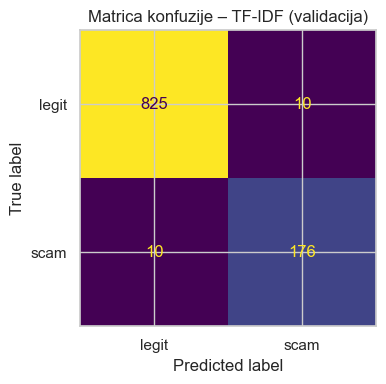

In [10]:
y_val_pred_tfidf = clf_tfidf.predict(X_val_tfidf)
y_val_prob_tfidf = clf_tfidf.predict_proba(X_val_tfidf)[:, 1]

print("=== TF-IDF + LR – validacijski skup ===")
print(classification_report(y_val, y_val_pred_tfidf, target_names=['legit', 'scam']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_tfidf,
    display_labels=['legit', 'scam'], ax=ax, colorbar=False
)
ax.set_title('Matrica konfuzije – TF-IDF (validacija)')
plt.tight_layout()
plt.show()

TF-IDF model postiže odlične rezultate već na validacijskom skupu: F1 za scam klasu iznosi 0.95, uz ukupnu accuracy od 0.98. Precision i recall su ujednačeni (oba 0.95), što znači da model podjednako dobro prepoznaje scam poruke i ne generiše previše lažnih uzbuna. Ovi rezultati ne iznenađuju — scam poruke i spam imaju jako prepoznatljive leksičke obrasce koje TF-IDF efikasno hvata (placeholder tokeni `<PHONE>`, `<URL>`, tipične fraze).

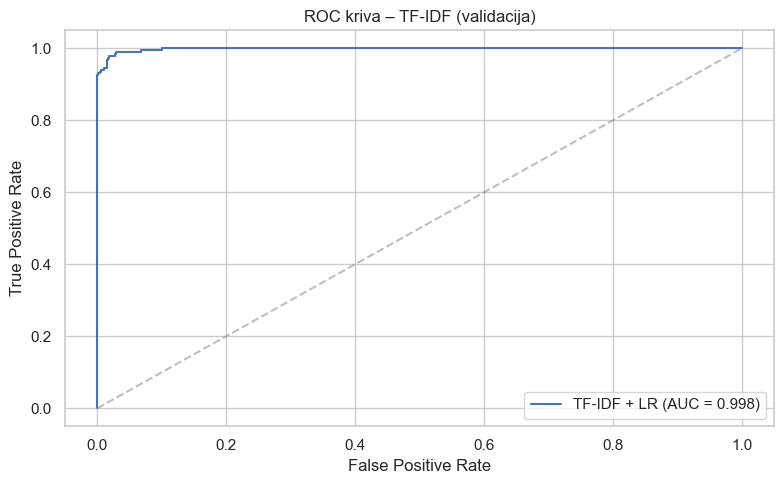

ROC-AUC (validacija): 0.9982


In [11]:
fpr_tv, tpr_tv, _ = roc_curve(y_val, y_val_prob_tfidf)
auc_tv = roc_auc_score(y_val, y_val_prob_tfidf)

plt.figure()
plt.plot(fpr_tv, tpr_tv, label=f'TF-IDF + LR (AUC = {auc_tv:.3f})')
plt.plot([0, 1], [0, 1], '--', color='grey', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC kriva – TF-IDF (validacija)')
plt.legend()
plt.tight_layout()
plt.show()
print(f"ROC-AUC (validacija): {auc_tv:.4f}")

ROC-AUC od **0.998** na validacijskom skupu ukazuje na gotovo savršenu sposobnost razlikovanja klasa. Kriva je praktično zalijepljena za gornji lijevi ugao, što znači da model s visokom pouzdanošću rangira scam poruke ispred legitimnih pri bilo kojoj granici odluke.

## Oblik 2: Duboka kontekstualna reprezentacija (Sentence-BERT)

Korišten je model `all-MiniLM-L6-v2` iz `sentence-transformers` biblioteke - transformer koji svaki tekst mapira u fiksni 384-dimenzionalni vektor semantičkog značenja.
Za razliku od TF-IDF-a, ovi vektori nose kontekstualno razumijevanje teksta - slične poruke bit će blizu u vektorskom prostoru čak i ako nemaju zajedničke riječi.
Isti tip klasifikatora (logistička regresija) primijenjen je radi fer poređenja s TF-IDF pristupom.
Za enkodiranje korišten je originalni tekst (`text` kolona) jer BERT-ov tokenizator sam vrši normalizaciju.

In [12]:
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer('all-MiniLM-L6-v2')

print("Enkodiranje trening skupa...")
E_train = sbert.encode(train['text'].fillna('').tolist(), batch_size=64, show_progress_bar=True)
print("Enkodiranje validacijskog skupa...")
E_val = sbert.encode(val['text'].fillna('').tolist(), batch_size=64, show_progress_bar=True)
print("Enkodiranje testnog skupa...")
E_test = sbert.encode(test['text'].fillna('').tolist(), batch_size=64, show_progress_bar=True)

print(f"\nDimenzija embedding vektora: {E_train.shape[1]}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\Korisnik\Desktop\dap projekat\dating-nlp\.venv-1\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Korisnik\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Enkodiranje validacijskog skupa...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Enkodiranje testnog skupa...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Dimenzija embedding vektora: 384


=== Sentence-BERT + LR – validacijski skup ===
              precision    recall  f1-score   support

       legit       0.99      0.99      0.99       835
        scam       0.94      0.97      0.96       186

    accuracy                           0.98      1021
   macro avg       0.97      0.98      0.97      1021
weighted avg       0.98      0.98      0.98      1021



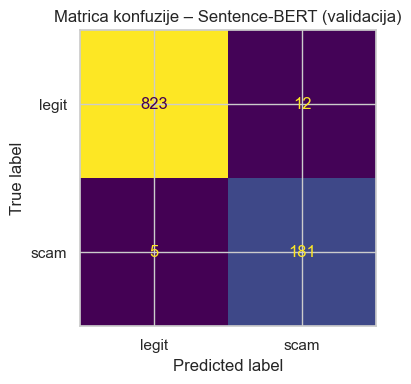

In [13]:
clf_sbert = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)
clf_sbert.fit(E_train, y_train)

y_val_pred_sbert = clf_sbert.predict(E_val)
y_val_prob_sbert = clf_sbert.predict_proba(E_val)[:, 1]

print("=== Sentence-BERT + LR – validacijski skup ===")
print(classification_report(y_val, y_val_pred_sbert, target_names=['legit', 'scam']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_sbert,
    display_labels=['legit', 'scam'], ax=ax, colorbar=False
)
ax.set_title('Matrica konfuzije – Sentence-BERT (validacija)')
plt.tight_layout()
plt.show()

Sentence-BERT postiže sličnu accuracy (0.98), ali s nešto drugačijim rasporedom grešaka. Recall za scam klasu je **0.97** - viši nego kod TF-IDF-a (0.95), što znači da BERT propušta manje stvarnih scam poruka. Precision je neznatno niži (0.94 vs 0.95), tj. nešto više legitimnih poruka je pogrešno označeno kao scam. Na validacijskom skupu, BERT ostvaruje bolji recall uz minimalno smanjenje precision-a.

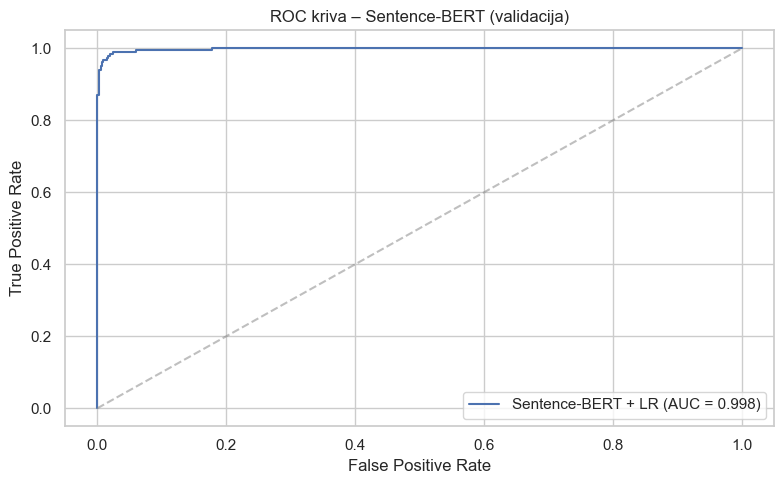

ROC-AUC (validacija): 0.9980


In [14]:
fpr_sv, tpr_sv, _ = roc_curve(y_val, y_val_prob_sbert)
auc_sv = roc_auc_score(y_val, y_val_prob_sbert)

plt.figure()
plt.plot(fpr_sv, tpr_sv, label=f'Sentence-BERT + LR (AUC = {auc_sv:.3f})')
plt.plot([0, 1], [0, 1], '--', color='grey', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC kriva – Sentence-BERT (validacija)')
plt.legend()
plt.tight_layout()
plt.show()
print(f"ROC-AUC (validacija): {auc_sv:.4f}")

ROC-AUC od **0.998** — gotovo identičan TF-IDF-u. U ovoj fazi oba pristupa pokazuju sličnu ukupnu diskriminativnu moć, a razlika se vidi tek u detaljnom rasporedu precision/recall.

## Evaluacija na testnom skupu

Nakon odabira i provjere modela na validacijskom skupu, finalna evaluacija rađena je na odvojenom testnom skupu koji nije korišten ni u jednoj fazi treniranja.

In [15]:
y_test_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
y_test_prob_tfidf = clf_tfidf.predict_proba(X_test_tfidf)[:, 1]

y_test_pred_sbert = clf_sbert.predict(E_test)
y_test_prob_sbert = clf_sbert.predict_proba(E_test)[:, 1]

print("=== TF-IDF + LR – testni skup ===")
print(classification_report(y_test, y_test_pred_tfidf, target_names=['legit', 'scam']))

print("=== Sentence-BERT + LR – testni skup ===")
print(classification_report(y_test, y_test_pred_sbert, target_names=['legit', 'scam']))

=== TF-IDF + LR – testni skup ===
              precision    recall  f1-score   support

       legit       0.99      0.99      0.99       835
        scam       0.97      0.96      0.96       186

    accuracy                           0.99      1021
   macro avg       0.98      0.98      0.98      1021
weighted avg       0.99      0.99      0.99      1021

=== Sentence-BERT + LR – testni skup ===
              precision    recall  f1-score   support

       legit       0.99      0.98      0.98       835
        scam       0.92      0.95      0.93       186

    accuracy                           0.98      1021
   macro avg       0.95      0.97      0.96      1021
weighted avg       0.98      0.98      0.98      1021



Na testnom skupu razlike između modela postaju jasnije. TF-IDF ostvaruje F1 od **0.96** za scam klasu, dok Sentence-BERT postiže **0.93**. Zanimljivo je da TF-IDF na testnom skupu ima i viši recall (0.96 vs 0.95), suprotno situaciji na validacijskom skupu gdje je BERT imao prednost u recall-u. Oba modela su konzistentna između val i test skupova, bez znakova prenapasivanja.

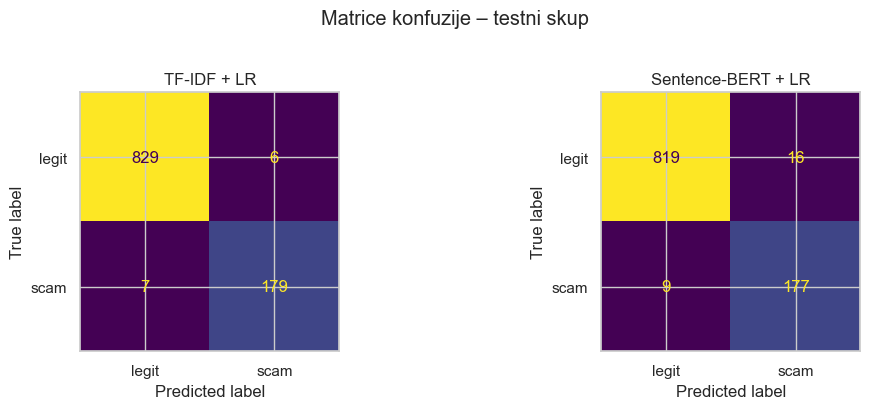

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_tfidf,
    display_labels=['legit', 'scam'], ax=axes[0], colorbar=False
)
axes[0].set_title('TF-IDF + LR')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_sbert,
    display_labels=['legit', 'scam'], ax=axes[1], colorbar=False
)
axes[1].set_title('Sentence-BERT + LR')

plt.suptitle('Matrice konfuzije – testni skup', y=1.02)
plt.tight_layout()
plt.show()

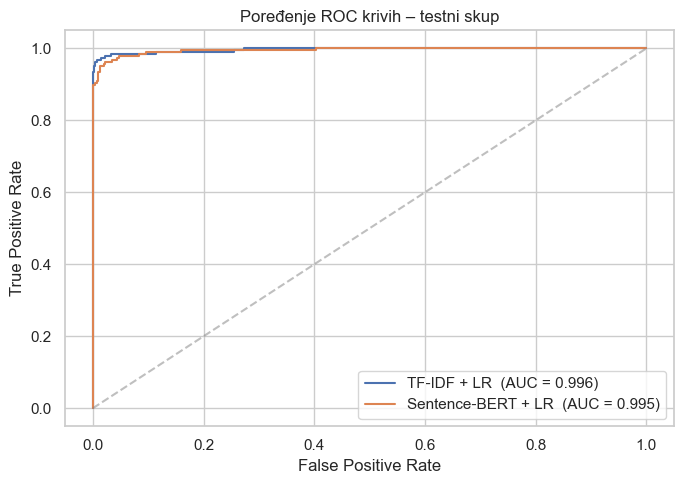

In [17]:
fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob_tfidf)
auc_t = roc_auc_score(y_test, y_test_prob_tfidf)
fpr_s, tpr_s, _ = roc_curve(y_test, y_test_prob_sbert)
auc_s = roc_auc_score(y_test, y_test_prob_sbert)

plt.figure(figsize=(7, 5))
plt.plot(fpr_t, tpr_t, label=f'TF-IDF + LR  (AUC = {auc_t:.3f})')
plt.plot(fpr_s, tpr_s, label=f'Sentence-BERT + LR  (AUC = {auc_s:.3f})')
plt.plot([0, 1], [0, 1], '--', color='grey', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Poređenje ROC krivih – testni skup')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
def get_metrics(y_true, y_pred, y_prob, name):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision (scam)': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall (scam)': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1 (scam)': round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_true, y_prob), 4),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_test_pred_tfidf, y_test_prob_tfidf, 'TF-IDF + LR'),
    get_metrics(y_test, y_test_pred_sbert, y_test_prob_sbert, 'Sentence-BERT + LR'),
]).set_index('Model')

results

,Accuracy,Precision (scam),Recall (scam),F1 (scam),ROC-AUC
Model,,,,,
TF-IDF + LR,0.9873,0.9676,0.9624,0.965,0.9956
Sentence-BERT + LR,0.9755,0.9171,0.9516,0.934,0.9945


TF-IDF + LR nadmašuje Sentence-BERT + LR na svim metrikama na testnom skupu. Razlog vjerovatno leži u karakteru podataka - SMS spam i sintetički scam profili imaju jako prepoznatljive i ponavljajuće leksičke obrasce. TF-IDF-u to ide u prilog jer direktno mjeri frekvenciju tih karakterističnih tokena. Sentence-BERT donosi semantičku generalizaciju koja u ovom slučaju nije korisna jer su obrasci u podacima konzistentni i predvidivi.

## Zaključak

Oba modela postižu visok ROC-AUC (>0.998), što potvrđuje da je problem detekcije prevara u ovom datasetu relativno dobro rješiv.

TF-IDF + logistička regresija se pokazao kao bolji pristup na svim metrikama (F1: 0.965 vs 0.934). Razlog leži u prirodi podataka - SMS spam i sintetički generisani scam profili nose jako prepoznatljive leksičke obrasce koje TF-IDF direktno hvata. Semantička generalizacija koju nudi Sentence-BERT ovdje nije donijela prednost, jer su obrasci previše predvidivi i ponavljajući.

Ključno ograničenje je što sintetički scam profili prate fiksirane šablone, pa postoji rizik da su oba modela previše prilagođena tim obrascima. U realnoj primjeni model bi trebalo testirati na raznovrsnijim primjerima stvarnih prevara iz dating aplikacija, gdje su formulacije znatno varijabilnije.